In [194]:
import numpy as np ##From lectures 1:1 
import matplotlib.pyplot as plt
import time


def thomas_algorithm(a, b, c, d):# From Slides 
    """
    Solve the tridiagonal system using the Thomas algorithm.

    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)

    Returns: solution vector x of length n
    """

    n = len(b)

    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]

    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]

    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]

    return x



def solveSpline(x, y, xValue):

    h = [] ##empty array 
    for i in range(len(x) - 1): ##number of calculations (h2-h1 type) within array
        h.append(x[i+1] - x[i]) 

    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(len(x) - 2)  # Subdiagonal
    B = np.zeros(len(x) - 2)  # Main diagonal
    C = np.zeros(len(x) - 2)  # Superdiagonal
    D = np.zeros(len(x) - 2)  # Right-hand side vector

    # Populate the tridiagonal matrix coefficients
    count = 0
    for i in range(1, len(x) - 1):
       # count = x[i] 
        #if (i = 1):
        #    A[i - 1] = 0 
        #elif (i > 1):
        ##    for ()
        A[i - 1] =  h[i-1]       # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i])        # Main diagonal
        C[i - 1] = h[i]        # Superdiagonal 
        D[i - 1] = 6 * ( (y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1]  )       # Right-hand side vector


    
    mInterior =  thomas_algorithm(A, B, C, D)
    
    m = np.zeros(len(x))
    for i in range (1, len(x) - 1) :
        m[i] = mInterior[i-1] ##finding inner m values, 


    for i in range (len(x) - 1):
        if (x[i] <= xValue and xValue <= x[i+1]): ##finding which "i" the xValue from input pertains, find the value from the spline using interpolation
        ##solving for the splice 
            S = (
            ( m[i] / (6 * h[i] )) * (x[i+1]  - xValue)**3 +
            ( m[i+1] / ( 6 * h[i]) ) * (xValue - x[i] )**3 +
            ( y[i] / h[i] - m[i] * h[i] / 6) * (x[i+1] - xValue ) +
            ( y[i+1] / h[i] - m[i+1] * h[i] /6 ) * (xValue - x[i] )
            ) ##formula from slide s
            
            return S

    
##Part B 

def vandermond (vector, degree): ##Returns what np.vander() does, self-explanatory, returns an array of "vector" length, each mdae up of a subsequent increase in degree until it matches that of the input
    term = []
    output = []

    
    for i in range(len(vector)):
        j = degree 
        while (j > -1):
            term.append(vector[i]**j)
            j = j -1

        output.append(term)
        term = []
        
    return output
            
def leastSquare (vector1, vector2, degree): ## Pulled from homework 5 
    
    xtotal = 0 
    ytotal = 0
    xy = 0 
    xSquared = 0
    
    # Vandermond Matrix 
    ##np.vander
    
    a = vandermond(vector1, degree)
    a = np.array(a)

    
    
    # Solving System of Linear Equations, sourced from slides 
    
    # a.T * vector2(y)
    VT_V = np.dot(a.T, a)

    # a.T * y
    VT_y = np.dot(a.T, vector2)

    # Solve for a (coefficients)
    coefficients = np.linalg.solve(VT_V, VT_y)
    return coefficients 
    
    
    


# Part A 

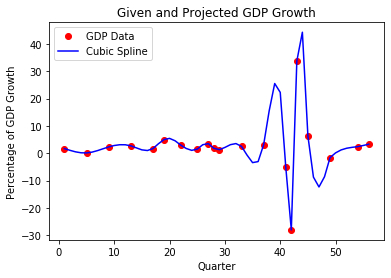

C0 check (should be ~0): 8.873667196818147e-06
C1 check (should be ~0): 1.0132539252083461e-05
C2 check (should be ~0): 0.00013322676295501878


In [195]:
##Part A 
import numpy as np
import matplotlib.pyplot as plt
import time 
x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, ##AI utilized to get values for this array / dataset, as in to extract from slides
              29, 33, 37, 41, 42, 43, 45, 49, 54, 56])

y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
              1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

xCompleted = []
for i in range (1, 57):
    xCompleted.append(i)
plt.plot(x, y, 'ro', label="GDP Data")
plt.ylabel("Percentage of GDP Growth")
plt.xlabel("Quarter")
plt.title("Given and Projected GDP Growth")


splineValues = []
for i in range (1, 57):
    splineValues.append(solveSpline(x, y, i))
 

plt.plot(xCompleted, splineValues, 'b-', label="Cubic Spline")

plt.legend()
plt.show()
epsilon = 1e-5


#The following utilized AI to check the knots and Cs 

# Continuity Verification at interior knot x[10] 
epsilon = 1e-5

# C0: value from left and right should match at knot
left  = solveSpline(x, y, x[10] - epsilon)
right = solveSpline(x, y, x[10] + epsilon)
print("C0 check (should be ~0):", abs(left - right))

# C1: first derivative from left vs right segment
left_d1  = (solveSpline(x, y, x[10]) - solveSpline(x, y, x[10] - epsilon)) / epsilon
right_d1 = (solveSpline(x, y, x[10] + epsilon) - solveSpline(x, y, x[10])) / epsilon
print("C1 check (should be ~0):", abs(left_d1 - right_d1))

# C2: second derivative from left segment vs right segment at knot
d2_left  = (solveSpline(x, y, x[10] - epsilon) - 2*solveSpline(x, y, x[10] - epsilon/2) + solveSpline(x, y, x[10])) / (epsilon/2)**2
d2_right = (solveSpline(x, y, x[10]) - 2*solveSpline(x, y, x[10] + epsilon/2) + solveSpline(x, y, x[10] + epsilon)) / (epsilon/2)**2
print("C2 check (should be ~0):", abs(d2_left - d2_right))




    



    
    
   



    
    
   

# Part B, Part 1

Condition number: 331159858930772.8


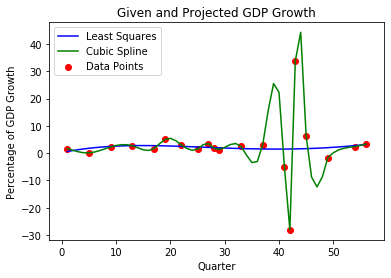

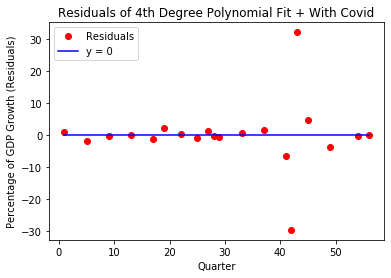

The RMSE value is: 10.031440678677116


In [196]:
#Part B, Part 1 
import numpy as np
import matplotlib.pyplot as plt

##Repeat from Part A 
x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, ##AI utilized to get values for this array / dataset, as in to extract from slides
              29, 33, 37, 41, 42, 43, 45, 49, 54, 56])

y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
              1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])


#Least Squares Graphing 
xCompleted = np.arange(1, 57)
     
slopeLeastSquared = leastSquare(x, y, 4) ##Instructions say degree four, order of input is x values as above, y values as above, and the 4th degree
predictY = (slopeLeastSquared[0]*(xCompleted**4) + slopeLeastSquared[1]*(xCompleted**3) + slopeLeastSquared[2]*(xCompleted**2) + slopeLeastSquared[3]*xCompleted + slopeLeastSquared[4]) ##Utilized CHATGPT to debug this specific line of code for a long time, it was going in ascending order instead of descending and this was causing issues

# Condition number check - AI Utilization 
a = np.array(vandermond(x, 4))
VT_V = np.dot(a.T, a)
print("Condition number:", np.linalg.cond(VT_V))


plt.plot(xCompleted, predictY, color="blue", label="Least Squares")
plt.xlabel("Quarter")
plt.ylabel("Percentage of GDP Growth")
plt.title("Given and Projected GDP Growth")
plt.scatter(x, y, color="red", label="Data Points")



#Cubic Spline Graphing 
xCompleted = []
for i in range (1, 57):
    xCompleted.append(i)
plt.ylabel("Percentage of GDP Growth")
plt.xlabel("Quarter")
plt.title("Given and Projected GDP Growth")


splineValues = []
for i in range (1, 57):
    splineValues.append(solveSpline(x, y, i))
 
plt.plot(xCompleted, splineValues,'g-', label="Cubic Spline")
plt.legend()
plt.show()


##Residual Plot 
#same as predictY on top but instead of doing it for all 56 values instead we are utilizing it for only the values that we have the actual data points are, to retrofit how far off the original equation is
predictY = (slopeLeastSquared[0]*(x**4) + slopeLeastSquared[1]*(x**3) + slopeLeastSquared[2]*(x**2) + slopeLeastSquared[3]*x + slopeLeastSquared[4]) ##Utilized CHATGPT to debug this specific line of code for a long time, it was going in ascending order instead of descending and this was causing issues

residual = y - predictY  
plt.plot(x, residual, 'ro', label="Residuals")
plt.plot(x, [0]*len(x), 'blue', label="y = 0")
plt.xlabel("Quarter")
plt.ylabel("Percentage of GDP Growth (Residuals)")
plt.title("Residuals of 4th Degree Polynomial Fit + With Covid") 
plt.legend()
plt.show()

##The farther the residual points are from y = 0, the higher the deviancy is from the original plot. This means that espeecially during the covid years there is an extremely high deviance from the given data points, to the given actual values. 


# RMSE calculation 
residualSum = 0
for i in range (len(residual)):
    residualSum = residualSum + residual[i] * residual[i]
RMSE = (residualSum / len(residual)) ** .5

print("The RMSE value is: " + str(RMSE) )





# Part B, Part 2 

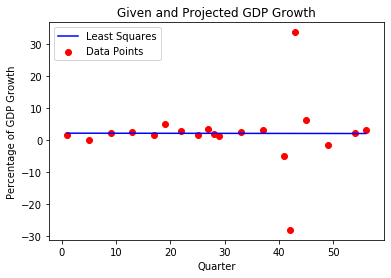

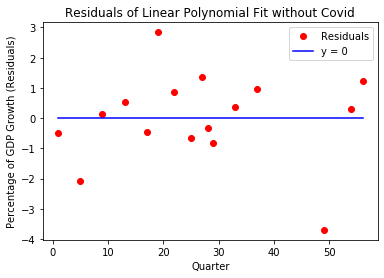

The RMSE value is: 1.4431864883291987
The slope value is: -0.0019069881889763906


In [197]:
#Part B
#Part 2 

import numpy as np
import matplotlib.pyplot as plt
import time

##Repeat from Part A + Part B 
x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, ##AI utilized to get values for this array / dataset, as in to extract from slides
              29, 33, 37, 41, 42, 43, 45, 49, 54, 56])

y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
              1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

##Covidless quarters from array are when x do not equal 13, 14, 15, 16 
xCovidless = []
yCovidless = []
for i in range (0, len(x)):
    if (i != 13 and i!= 14 and i!= 15 and i!= 16):
        xCovidless.append(x[i])
        yCovidless.append(y[i])
     

#Least Squares Graphing 
xCompleted = np.arange(1, 57)
     
#Says it will be linear so that means that degree is 1 
slopeLeastSquared = leastSquare(xCovidless, yCovidless, 1) ##Instructions say degree four, order of input is x values as above, y values as above, and the 4th degree
predictY = slopeLeastSquared[1] + xCompleted*slopeLeastSquared[0]

plt.plot(xCompleted, predictY, color="blue", label="Least Squares")
plt.xlabel("Quarter")
plt.ylabel("Percentage of GDP Growth")
plt.title("Given and Projected GDP Growth")
plt.scatter(x, y, color="red", label="Data Points")
plt.legend()
plt.show()

##It makes sense to plot the graph linearly because the data points excluding covid have very little deviation. Thus, it makes perfect sense from an overall GDP standpoint. However, from a year to year standpoint looking at extremely short term economic growth, it is poor because it is dificult to ascertian the month by month fluctuations. This graph however is great for macro, decades long points of data. It requries the assumption that this will be utilized in my opinion on a much lengthier period of scale where small flucations do not matter as much

# Residuals 
predictY = np.array(slopeLeastSquared[0])*np.array(xCovidless) + np.array(slopeLeastSquared[1])
residual = np.array(yCovidless) - predictY  
plt.plot(xCovidless, residual, 'ro', label="Residuals")
plt.plot(xCovidless, [0]*len(xCovidless), 'blue', label="y = 0")
plt.xlabel("Quarter")
plt.ylabel("Percentage of GDP Growth (Residuals)")
plt.title("Residuals of Linear Polynomial Fit without Covid")
plt.legend()
plt.show()

          # RMSE calculation - adapted from part B1 
residualSum = 0
for i in range (len(residual)):
    residualSum = residualSum + residual[i] * residual[i]
RMSE = (residualSum / len(residual)) ** .5

print("The RMSE value is: " + str(RMSE) )
print("The slope value is: " + str(slopeLeastSquared[0]))

##Partial AI utilization in Big O fact checking and sourcing of proper notation.  
   


Introduction: The dataset provided is a list of quarters in a fiscal year, along with GDP growth within that quarter. The data originates from the U.S. Bureau of Economic Analysis (BEA) and is given in the project PDF. In this project, I have utilized Cubic Spline and Least Squares methods to interpolate points on the graph. Furthermore, residuals and RMSE were calculated for the benefit of the Least Squared method. 

Cubic Spline Note:
At C of 0, the spline is completely continuous
At C of 1, the first derivatives match the knot in the interior
At C of 2, the second derivative is equal to the interior of the note (“m”)

The make-up of the Cubic Spline calculation guarantees the continuity which the above note seeks to address, in that it is compatible with the Spline format. According to the calculation given for C of 0, C of 1, and C of 2, they all fulfill the qualifications set out in the instructions. (See part A)

Part A:
The Cubic Spline is a means of interpolating where through a series of points, a third degree polynomial is created to account for the span between these two points. To solve the Cubic Spline a series of equations is solved in order to determine the value of each “m” at each point given as a value. We know that the first M, and the last M are 0, so a system of equations is utilized in order to find the coefficients of these interior Ms, the Thomas Equation solved the Ms. Using the Ms, the y values can be predicted at every X. The graph showed that the results were extremely accurate in predicting the y values of all quarters (x values). This was true with both covid taken into account, and covidless data.

1. Here, there are 20 given quarters, and we know the “m” of the 1st and of the 20th index are 0. There are 18 unknown “m” values between the first and last “m” value. It is the definition of a cubic spline that the first and last “m” are equal to 0 (because they are the end points). The first and last “m” value then is “M” of index 0 and “M” of index 19. So, we have 18 unknowns, and there are 18 equations to solve for these 18 unknowns. In the above paragraph, it is detailed how each of the unknown “M” values was solved.


2. The interpolant is smooth and reasonable in the years flanking the COVID years. COVID years notwithstanding, this is because there is a clear trend between knots that adequately demonstrates a reasonable trend in the economy between those two given data points. There are no sudden jumps in the data that are not explained by the apparent trend between the knots, and all is well in how the interpolated points align with the given data. However, around the outliers of the COVID years, there are indeed sharp turns in the DATA, showing a lack of numeric stability. 

3. According to my data, the point exactly matches the given (-28.1%). The runge phenomenon is indeed present between quarters ~35 to ~39, where there is a sharp jump in the data as a whole. The Cubic Spline forces it self to go through each of the data poitns which is good; however, it is apparent that it is doing so at the cost of the natural flow of data. So it is quite unnatural in this small subsection of the data. This is, however, the exact interpolation of the values… The numerical stability, though, is compromised here as the Cubic Spline is the mechanism being used for the graphing of the data. I believe smoothing splines would be preferably here because it would have the benefits of the spline with the interpolation; however, it would be evened out by caring for the numerical stability. I do not believe least squares would be the best option either because it would be the worst of both worlds, not interpolated optimally, and the numerical stability will still be a bit off.

Part B:
The second method that is utilized is Least Squares. A separate Vandermond function was made. The least squares made was akin to a “line of best fit” of the values. A system of equations was again made here, but instead solved by “np.linalg.solve”, for the variables a,b,c,d. Residual calculations were done on both of the Least Squares methods, which showed that the results were not accurate in interpolating the values of the data, at least not as accurately as the cubic spline. Especially during the Covid years, the value fell short of being accurate, while Cubic Spline excelled for both the COVID and Covidless data taken into account. Even with the Covid values removed, the least Squares graphs of residuals was still not extremely accurate, with there being large deviances from the y= 0 mark, indicating where values are most accurate.

1. The cubic spline interpolates the value of each point while ensuring that the graph still passes through the given data points, while the polynomial graph does not pass through the given data points, yet still ensures numerical stability. The better of these for this data is the cubic spline, because in economics, it is vital for figures in the data to be 1:1 to the given data points. The reason for this is that in economics, the value of the economy must be exact in order to have proper measures taken to alleviate or promote its health. Furthermore, in terms of political credibility, it would hurt the reputation of the regime for the economy to be lower than what it is in actuality, or it will be seen as lying if it is higher than what it is in actuality. This shows the apparent tradeoff between the Cubic Spline and Least Squares, in that the Cubic Spline is more accurate on a bar for bar basis, quarter-to-quarter and the micro trends. However, for the overall picture of the economy, the Least Squares is by far superior, in that it shows the overall trend of the economy as a whole. It demonstrates how the economy has changed over time, and where it is likely to go if the trend continues.
2. The slope of Part B #2 is -.0019. This means that the slope of the line of best fit of part 1 has little slope magnitude. This shows that the economy has a negative trajectory, albeit miniscule. As time continues, and assuming the trend continues, the economy will be in recession, though barely. Keep in mind, this value is when COVID is excluded. So this means that the economy with COVID neglected was overall relatively stable (though still experiencing economic downsizing)

#Part C

1. The better choice is Cubic Spline because the graph for one is more fluid, making it more reasonable to read, the graph goes through each data point, making it more accurate for the values interpolated in unknown x values. The accuracy of the cubic spline is, at the very least is accurate to the given data points, while polynomial fitting only goes through a handful of points. As mentioned previously, with polynomial approximations that are not true to the original data points, it is possible for the economic data to be higher than it is in actuality, which would be lying to the public, or it would be lower than what it actually is, which would make the regime look needlessly bad. The RMSE value of the B1 graph was roughly 10.031, and the RMSE value of the B2 graph was 1.44. A higher RMSE means the values are a worse fit. However, just because the RMSE values are lower does not necessarily mean it is superior, as one graph could still more properly demonstrate the overall trend of the graph, in a way that the other graph is inferior in.  This means that we were right about what was discussed earlier, in that without covid, a linear least squares graph does indeed make more sense to plot. The linear Least Squares polynomial graph does a better job than the Cubic Spline at showing the overall trend of the graph, however. In the Cubic Spline, it is far more difficult to see the overall upward trajectory of the economy, while in the Least Squares polynomial, it is clear as day.

#Big O Analysis
Big O notation is a means of denoting the time complexity of an algorithm as a function of the input size “n”. This will help determine the efficiency of the calculations themselves.

It can be extrapolated from the computation method of the Cubic Spline that it has an overall slightly higher runtime as the number of terms increases. This means that it is more efficient to run a Least Squares graph. This does not change the finding that Cubic Spline is the preferable mode of calculation, for the reason that any difference in calculation time would be extremely negligble, and for the purposes of an economic assentment in a real-life project, would prove insignificant. Evaluating the cubic spline is with O(m log n ) because at each evaluation point the function loops. Here, "m" is the number of points that are evaluated. The thomas algorithim, as explained earlier, is with O(n). The 4th degree Vandermonde is likewise a O(n) because the degree is fixed. The least squares method is with O(n*sqr(d)) with d being the degree of the polynomial. This would simplify to a O(n) since it would be a constant times n with the degree included in the parenthesis. 


Conclusion:
The dataset and graphs outlined above give a great understanding of the comparisons between Cubic Spline and Polynomial / Least Squares graphs. From the data gathered and their application, it is clear that the Cubic Spline is the superior method of graphing for the data given above, still, Least Squares / Polynomial does have considerable upsides, namely the ability to show the trajectory of the economy as time marches forward, instead of the more micro-level bears and bulls of the Cubic Spline.

